In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Bank_Stock_Price_10Y.csv", parse_dates=['Date'], index_col='Date')

# Quick inspection
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nInfo:")
print(df.info())

print("\nSummary statistics:")
print(df.describe())


Shape: (2483, 6)

First 5 rows:
              Open    High     Low   Close    Adj Close     Volume
Date                                                              
2014-02-03  1980.0  2000.0  1965.0  1965.0  1691.382568   55407000
2014-02-04  1970.0  1980.0  1940.0  1970.0  1695.686035   83683500
2014-02-05  1980.0  1990.0  1965.0  1990.0  1712.901367   42715000
2014-02-06  1975.0  2030.0  1970.0  2030.0  1747.331299   63581000
2014-02-07  2050.0  2060.0  2035.0  2050.0  1764.546753  104825500

Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2483 entries, 2014-02-03 to 2024-01-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2483 non-null   float64
 1   High       2483 non-null   float64
 2   Low        2483 non-null   float64
 3   Close      2483 non-null   float64
 4   Adj Close  2483 non-null   float64
 5   Volume     2483 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 135.8

In [6]:
# Check missing values
print("Missing values:\n", df.isnull().sum())

# Check for zero volume (suspicious rows)
print("\nRows with Volume = 0:")
print(df[df['Volume']==0])


Missing values:
 Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Rows with Volume = 0:
              Open    High     Low   Close    Adj Close  Volume
Date                                                           
2014-04-09  2190.0  2190.0  2190.0  2190.0  1885.052368       0
2014-07-09  2260.0  2260.0  2260.0  2260.0  1958.659790       0
2015-12-09  2605.0  2605.0  2605.0  2605.0  2290.925293       0
2016-03-11  2680.0  2680.0  2680.0  2680.0  2356.882813       0
2016-03-14  2680.0  2680.0  2680.0  2680.0  2356.882813       0
...            ...     ...     ...     ...          ...     ...
2019-06-05  5820.0  5820.0  5820.0  5820.0  5349.746582       0
2019-06-06  5820.0  5820.0  5820.0  5820.0  5349.746582       0
2019-06-07  5820.0  5820.0  5820.0  5820.0  5349.746582       0
2020-03-13  5560.0  5560.0  5560.0  5560.0  5126.927734       0
2020-03-16  5560.0  5560.0  5560.0  5560.0  5126.927734       0

[71 rows x 6 columns]


In [8]:
df = df[df['Volume'] != 0]
print("Shape after removing zero-volume rows:", df.shape)


Shape after removing zero-volume rows: (2412, 6)


In [10]:
# Daily return = percentage change in Adj Close
df['Daily_Return'] = df['Adj Close'].pct_change() * 100

# Quick look
print(df[['Adj Close','Daily_Return']].head())


              Adj Close  Daily_Return
Date                                 
2014-02-03  1691.382568           NaN
2014-02-04  1695.686035      0.254435
2014-02-05  1712.901367      1.015243
2014-02-06  1747.331299      2.010036
2014-02-07  1764.546753      0.985243


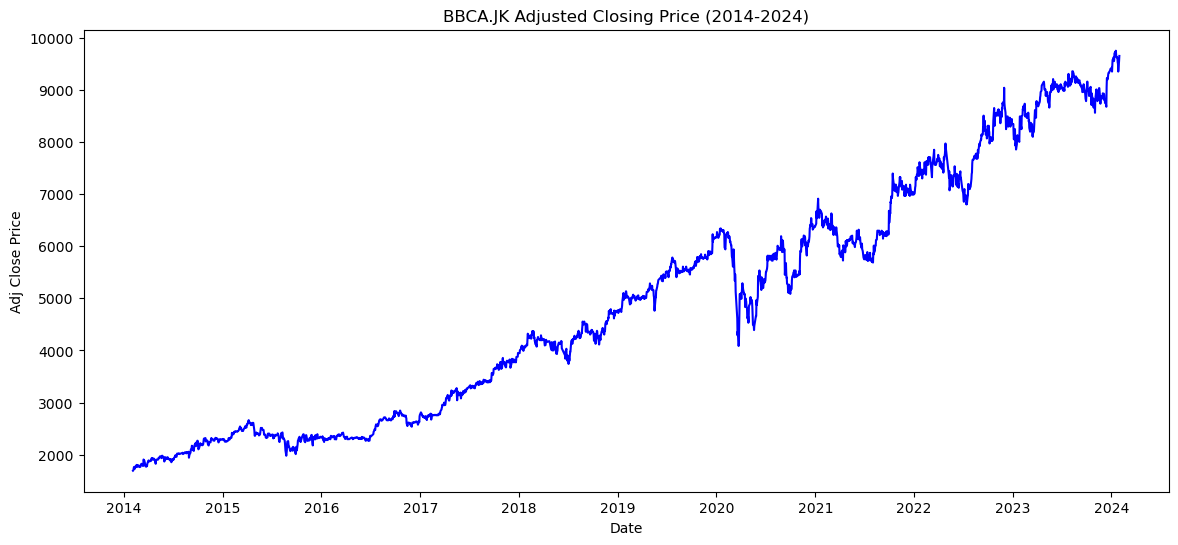

In [12]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Adj Close'], color='blue')
plt.title("BBCA.JK Adjusted Closing Price (2014-2024)")
plt.xlabel("Date")
plt.ylabel("Adj Close Price")
plt.show()


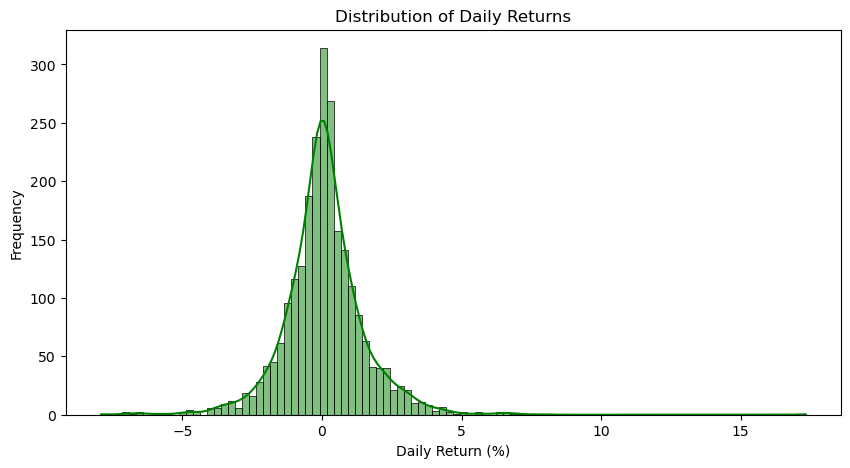

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df['Daily_Return'].dropna(), bins=100, kde=True, color='green')
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.show()


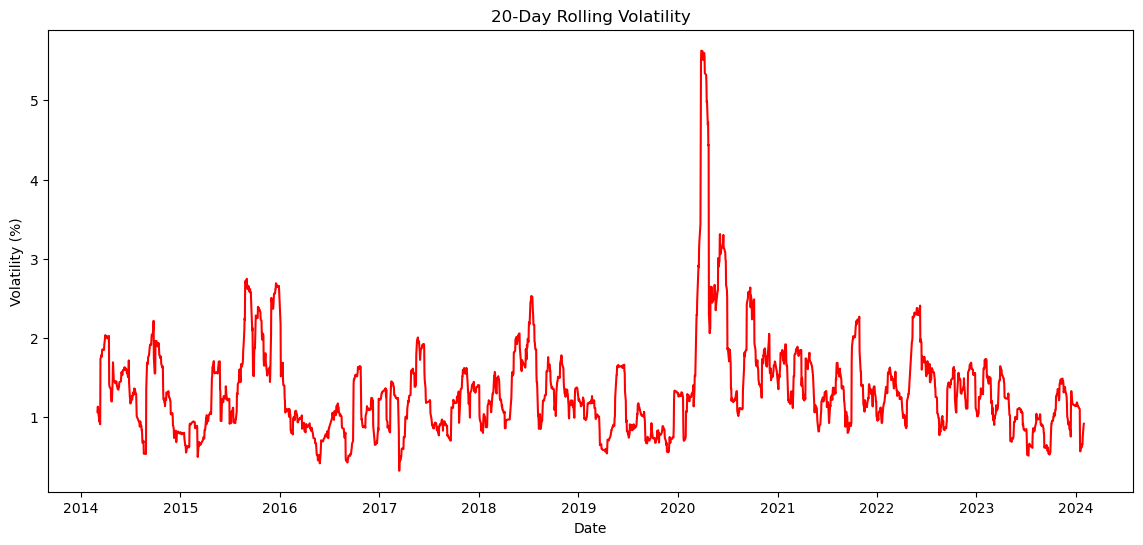

In [16]:
df['Rolling_Std'] = df['Daily_Return'].rolling(window=20).std()  # 20-day rolling volatility

plt.figure(figsize=(14,6))
plt.plot(df.index, df['Rolling_Std'], color='red')
plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.show()


In [32]:
# Target variable: 1 if next day's return > 0, else 0
df['Target'] = (df['Daily_Return'].shift(-1) > 0).astype(int)

print(df['Target'].value_counts())

# Drop the last row (NaN target)
df = df.dropna(subset=['Target'])

# Check
print(df[['Adj Close','Daily_Return','Target']].head())


Target
0    1273
1    1119
Name: count, dtype: int64
              Adj Close  Daily_Return  Target
Date                                         
2014-03-03  1768.850586      0.489018       1
2014-03-04  1803.280640      1.946465       1
2014-03-05  1816.191895      0.715987       1
2014-03-06  1820.495483      0.236957       1
2014-03-07  1824.799316      0.236410       0


In [20]:
# Moving averages
df['MA5'] = df['Adj Close'].rolling(window=5).mean()
df['MA10'] = df['Adj Close'].rolling(window=10).mean()

# Previous day return
df['Return_1'] = df['Daily_Return'].shift(1)
df['Return_2'] = df['Daily_Return'].shift(2)

# Drop rows with NaN from rolling calculations
df = df.dropna()

print(df.head())


              Open    High     Low   Close    Adj Close    Volume  \
Date                                                                
2014-03-03  2040.0  2065.0  2030.0  2055.0  1768.850586  86498000   
2014-03-04  2050.0  2105.0  2050.0  2095.0  1803.280640  96861000   
2014-03-05  2105.0  2115.0  2095.0  2110.0  1816.191895  76239000   
2014-03-06  2120.0  2130.0  2110.0  2115.0  1820.495483  96116500   
2014-03-07  2120.0  2135.0  2110.0  2120.0  1824.799316  90006500   

            Daily_Return  Rolling_Std  Target          MA5         MA10  \
Date                                                                      
2014-03-03      0.489018     1.068574       1  1771.432666  1779.179480   
2014-03-04      1.946465     1.135528       1  1774.875708  1780.470606   
2014-03-05      0.715987     1.127749       1  1784.343970  1785.635120   
2014-03-06      0.236957     1.053425       1  1793.812256  1788.647730   
2014-03-07      0.236410     1.037631       0  1806.723584  1791.2

In [24]:
from sklearn.model_selection import train_test_split

# Features and target
features = ['MA5','MA10','Return_1','Return_2']
X = df[features]
y = df['Target']

# Split 80% train, 20% test (time-series aware)
split_index = int(len(df)*0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5407098121085595

Confusion Matrix:
 [[248  13]
 [207  11]]

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.95      0.69       261
           1       0.46      0.05      0.09       218

    accuracy                           0.54       479
   macro avg       0.50      0.50      0.39       479
weighted avg       0.51      0.54      0.42       479



In [28]:
importances = model.feature_importances_
for feat, imp in zip(features, importances):
    print(f"{feat}: {imp:.3f}")



MA5: 0.244
MA10: 0.244
Return_1: 0.255
Return_2: 0.256


In [30]:
# Count of each class to handle imbalance as the model so far is not great, from here we are improving. again
print(df['Target'].value_counts())

#as there is o significant differnce, we dont do SMOTE or oversampling.


Target
0    1273
1    1119
Name: count, dtype: int64


In [36]:
#appraoch 2: Class weight : says pay more attention to minority class, here UP.
#a very small change.

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#small change not significant we can see from numbers.


Accuracy: 0.5386221294363257

Confusion Matrix:
 [[247  14]
 [207  11]]

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.95      0.69       261
           1       0.44      0.05      0.09       218

    accuracy                           0.54       479
   macro avg       0.49      0.50      0.39       479
weighted avg       0.50      0.54      0.42       479



In [50]:
#approach 3 : feature engineeering, creating more features.
df['MA5'] = df['Adj Close'].rolling(5).mean() #like before
df['MA10'] = df['Adj Close'].rolling(10).mean()

#rolling std captures risk — high volatility may signal market uncertainty.
df['Volatility_5'] = df['Daily_Return'].rolling(5).std()
df['Volatility_10'] = df['Daily_Return'].rolling(10).std()

#lag features(momentum) Previous returns influence next day movement.
df['Return_1'] = df['Daily_Return'].shift(1)
df['Return_2'] = df['Daily_Return'].shift(2)
df['Return_3'] = df['Daily_Return'].shift(3)

#Relative Strength Index (RSI) RSI > 70 → overbought, RSI < 30 → oversold
delta = df['Adj Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

#MACD (Moving Average Convergence Divergence) Shows trend strength and momentum
ema12 = df['Adj Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Adj Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema12 - ema26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

#Helps identify price extremes Bollinger Bands (Price Volatility)
df['BB_Mid'] = df['Adj Close'].rolling(20).mean()
df['BB_Upper'] = df['BB_Mid'] + 2*df['Adj Close'].rolling(20).std()
df['BB_Lower'] = df['BB_Mid'] - 2*df['Adj Close'].rolling(20).std()

#Volume spikes often precede significant price moves - volume features
df['Volume_Change'] = df['Volume'].pct_change()
df['Volume_MA5'] = df['Volume'].rolling(5).mean()
df['Volume_MA10'] = df['Volume'].rolling(10).mean()

features = ['MA5','MA10','Return_1','Return_2','Return_3',
            'Volatility_5','Volatility_10','RSI','MACD','MACD_Signal',
            'BB_Upper','BB_Lower','Volume_Change','Volume_MA5','Volume_MA10']




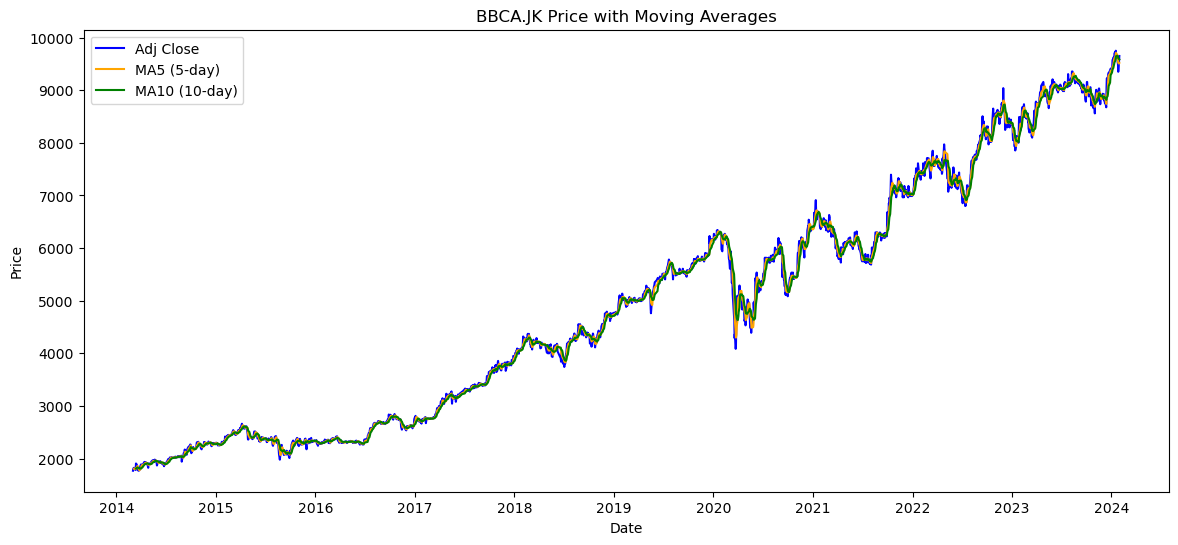

In [40]:


# Plot Adj Close and moving averages
plt.figure(figsize=(14,6))
plt.plot(df['Adj Close'], label='Adj Close', color='blue')
plt.plot(df['MA5'], label='MA5 (5-day)', color='orange')
plt.plot(df['MA10'], label='MA10 (10-day)', color='green')
plt.title('BBCA.JK Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


In [46]:
# Middle band = 20-day moving average of Adjusted Close
df['BB_Mid'] = df['Adj Close'].rolling(20).mean()

# Standard deviation over 20 days
rolling_std = df['Adj Close'].rolling(20).std()

# Upper and lower bands
df['BB_Upper'] = df['BB_Mid'] + 2 * rolling_std
df['BB_Lower'] = df['BB_Mid'] - 2 * rolling_std

print(df[['BB_Mid','BB_Upper','BB_Lower']].head(25))



                 BB_Mid     BB_Upper     BB_Lower
Date                                             
2014-03-03          NaN          NaN          NaN
2014-03-04          NaN          NaN          NaN
2014-03-05          NaN          NaN          NaN
2014-03-06          NaN          NaN          NaN
2014-03-07          NaN          NaN          NaN
2014-03-10          NaN          NaN          NaN
2014-03-11          NaN          NaN          NaN
2014-03-12          NaN          NaN          NaN
2014-03-13          NaN          NaN          NaN
2014-03-14          NaN          NaN          NaN
2014-03-17          NaN          NaN          NaN
2014-03-18          NaN          NaN          NaN
2014-03-19          NaN          NaN          NaN
2014-03-20          NaN          NaN          NaN
2014-03-21          NaN          NaN          NaN
2014-03-24          NaN          NaN          NaN
2014-03-25          NaN          NaN          NaN
2014-03-26          NaN          NaN          NaN


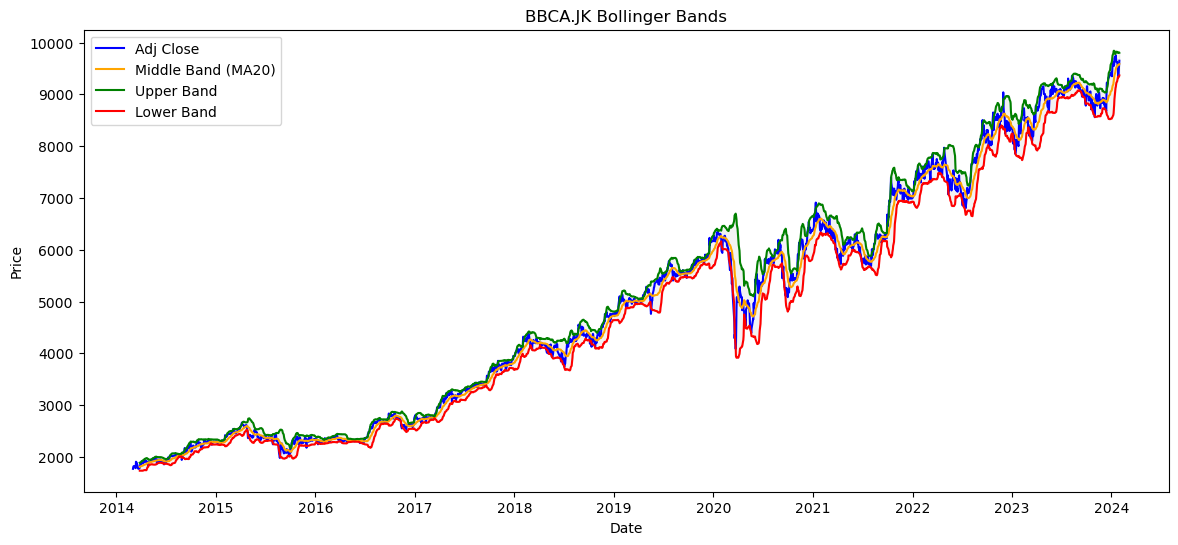

In [48]:
plt.figure(figsize=(14,6))
plt.plot(df['Adj Close'], label='Adj Close', color='blue')
plt.plot(df['BB_Mid'], label='Middle Band (MA20)', color='orange')
plt.plot(df['BB_Upper'], label='Upper Band', color='green')
plt.plot(df['BB_Lower'], label='Lower Band', color='red')
plt.fill_between(df.index, df['BB_Lower'], df['BB_Upper'], color='grey', alpha=0.1)
plt.title('BBCA.JK Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


In [52]:
import pandas as pd
import numpy as np

# Assuming df is your dataset with 'Adj Close', 'Daily_Return', 'Volume'

# --- Price-based features ---
df['MA5'] = df['Adj Close'].rolling(5).mean()
df['MA10'] = df['Adj Close'].rolling(10).mean()
df['Volatility_5'] = df['Daily_Return'].rolling(5).std()
df['Volatility_10'] = df['Daily_Return'].rolling(10).std()
df['Return_1'] = df['Daily_Return'].shift(1)
df['Return_2'] = df['Daily_Return'].shift(2)
df['Return_3'] = df['Daily_Return'].shift(3)

# --- Technical indicators ---
delta = df['Adj Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

ema12 = df['Adj Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Adj Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema12 - ema26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

df['BB_Mid'] = df['Adj Close'].rolling(20).mean()
df['BB_Upper'] = df['BB_Mid'] + 2*df['Adj Close'].rolling(20).std()
df['BB_Lower'] = df['BB_Mid'] - 2*df['Adj Close'].rolling(20).std()

# --- Volume features ---
df['Volume_Change'] = df['Volume'].pct_change()
df['Volume_MA5'] = df['Volume'].rolling(5).mean()
df['Volume_MA10'] = df['Volume'].rolling(10).mean()

# --- Target variable ---
df['Target'] = (df['Daily_Return'].shift(-1) > 0).astype(int)

# Drop rows with NaN
df = df.dropna()

# Features for model
features = ['MA5','MA10','Return_1','Return_2','Return_3',
            'Volatility_5','Volatility_10','RSI','MACD','MACD_Signal',
            'BB_Upper','BB_Lower','Volume_Change','Volume_MA5','Volume_MA10']


In [54]:
split_index = int(len(df)*0.8)
X_train, X_test = df[features][:split_index], df[features][split_index:]
y_train, y_test = df['Target'][:split_index], df['Target'][split_index:]


In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Random Forest with class weight
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.52

Confusion Matrix:
 [[200  60]
 [168  47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.77      0.64       260
           1       0.44      0.22      0.29       215

    accuracy                           0.52       475
   macro avg       0.49      0.49      0.46       475
weighted avg       0.50      0.52      0.48       475



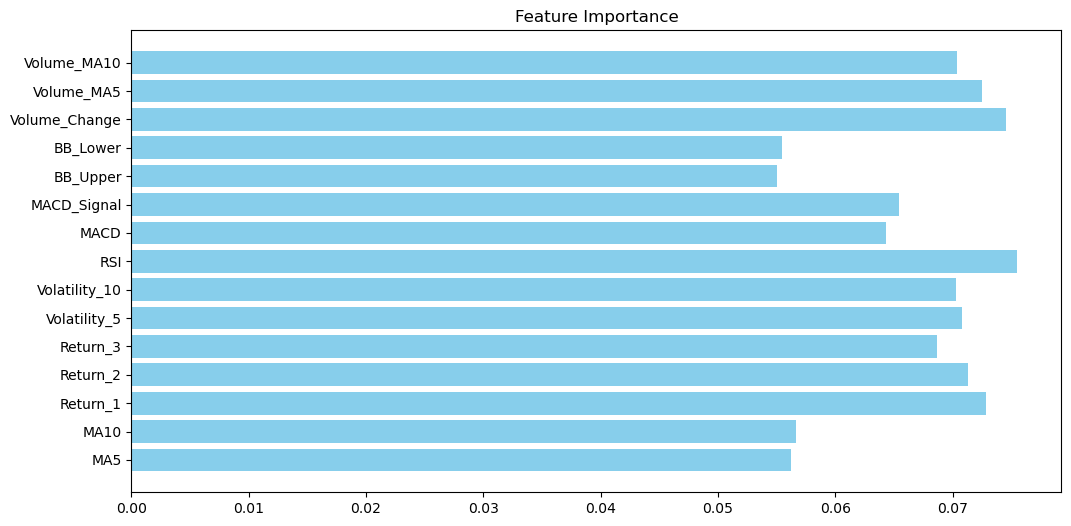

In [58]:
#Insights
#Feature engineering helped slightly (better than the earlier baseline)
#Recall for Up is still low (0.22) → model misses most Up days
#Precision for Up is moderate (0.44) → when model predicts Up, almost half are correct

importances = model.feature_importances_
plt.figure(figsize=(12,6))
plt.barh(features, importances, color='skyblue')
plt.title("Feature Importance")
plt.show()


In [60]:
#Threshold Tuning
#Default: model.predict() uses 0.5 probability threshold to decide Up/Down.
#For imbalanced or difficult-to-predict classes, you can lower threshold for Up:

# Predict probabilities for Up class
y_proba = model.predict_proba(X_test)[:,1]

# Lower threshold from 0.5 to 0.3 (experiment!)
threshold = 0.3
y_pred_threshold = (y_proba > threshold).astype(int)

# Evaluate
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred_threshold))
print(classification_report(y_test, y_pred_threshold))


[[  3 257]
 [  6 209]]
              precision    recall  f1-score   support

           0       0.33      0.01      0.02       260
           1       0.45      0.97      0.61       215

    accuracy                           0.45       475
   macro avg       0.39      0.49      0.32       475
weighted avg       0.39      0.45      0.29       475



TN = 3 → correctly predicted Down
FP = 257 → predicted Up, actually Down
FN = 6 → predicted Down, actually Up
TP = 209 → correctly predicted Up
Metrics: 
 
Class 0 (Down):
Precision = 0.33 → very low (only 33% of predicted Down were actually Down)
Recall = 0.01 → almost none of actual Down were captured
Class 1 (Up):
Precision = 0.45 → 45% of predicted Up were actually Up
Recall = 0.97 → almost all actual Up days were captured
What Happened?

You lowered the threshold for predicting Up → model now predicts Up almost all the time.
Result:
Recall for Up jumped → we catch almost all profitable Up days (good for trading)
Down days almost never predicted → low precision & recall for Down
Overall accuracy dropped → this is expected, because accuracy is misleading in imbalanced or low-signal datasets.

Why This Can Be Good in Finance

For a trading strategy: you care about catching Up days to make profit.
Even if you get some false positives (predict Up but market Down), you can manage risk with stop-loss or small positions.
High recall for Up is usually more valuable than high accuracy in buy/sell signal models.

Key Takeaways

Threshold tuning works → trade-off between recall & precision
Accuracy is not always the metric to optimize → focus on recall for the profitable class
Next step:
Add more features (momentum, RSI, MACD, Bollinger Bands)
Try XGBoost / LightGBM → better handling of subtle signals
Backtest cumulative returns → see if high Up recall translates to profit